In [12]:
import numpy as np
from astropy.modeling import models
from astropy import units as u
from matplotlib import pyplot as plt
from astropy import constants as const
from astropy.visualization import quantity_support
import scipy.integrate as integrate

In [13]:
Teff_room = 293*u.K
Teff_55k = 55*u.K
Teff_90k = 90*u.K

# detector area
A_det = (3.7*u.cm)**2
#pitch_pixels = 18*u.um
N_pixels = (2048*u.pix)**2
qe_det = 0.8
wavel_cuton = 1.0*u.um  
wavel_cutoff = 5.3*u.um

In [14]:
def wavel_to_nu(wav):
    # note wav needs to have units
    return (const.c / wav).to(u.Hz)

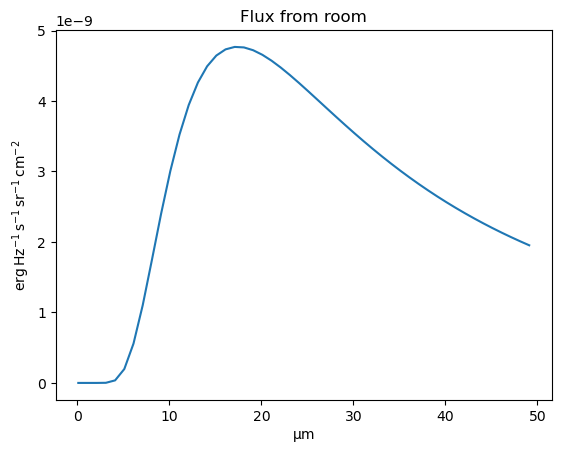

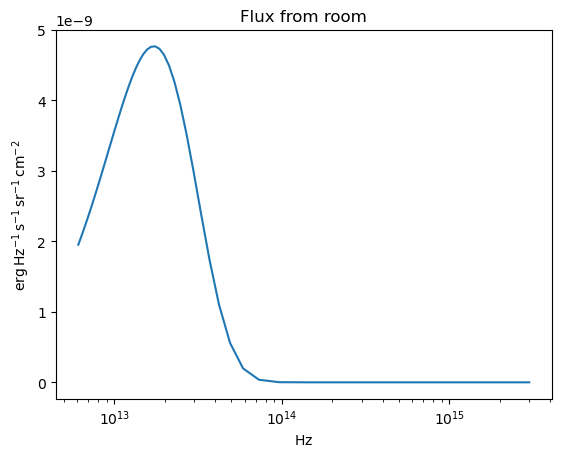

In [15]:
## Room temp first

bb_nu_room = models.BlackBody(temperature=Teff_room)
wav_room = np.arange(0.1, 50) * u.um
nu_room = wavel_to_nu(wav_room)

flux_nu_room_from_lambda = bb_nu_room(wav_room)
flux_nu_room_from_nu = bb_nu_room(nu_room)

# irradiance
with quantity_support():
    plt.figure()
    plt.plot(wav_room, flux_nu_room_from_lambda)
    plt.title('Flux from room')
    #plt.semilogx(wav, flux)
    #plt.xlim(0.1, 16)
    plt.show()

with quantity_support():
    plt.figure()
    plt.semilogx(nu_room, flux_nu_room_from_nu)
    plt.title('Flux from room')
    #plt.semilogx(wav, flux)
    #plt.xlim(0.1, 16)
    plt.show()


In [16]:
# number of photons

# break down into photons
def flux_nu_to_photons(flux_nu, nu):
    # input variables need to have units
    return (flux_nu / (const.h * nu)).decompose() * u.photon

nu_room = wavel_to_nu(wav_room)
flux_nu_room_photons = flux_nu_to_photons(flux_nu_room_from_nu, nu_room)

# integrate

In [22]:
print(nu_room.unit)
print(flux_nu_room_from_nu.unit)
print(flux_nu_room_photons.unit)

Hz
erg / (Hz s sr cm2)
ph / (m2 rad2)


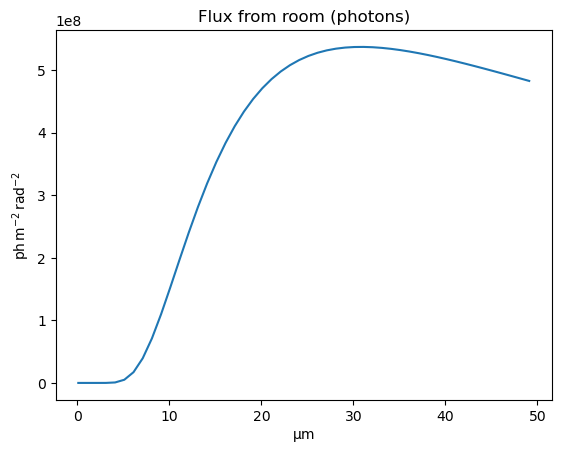

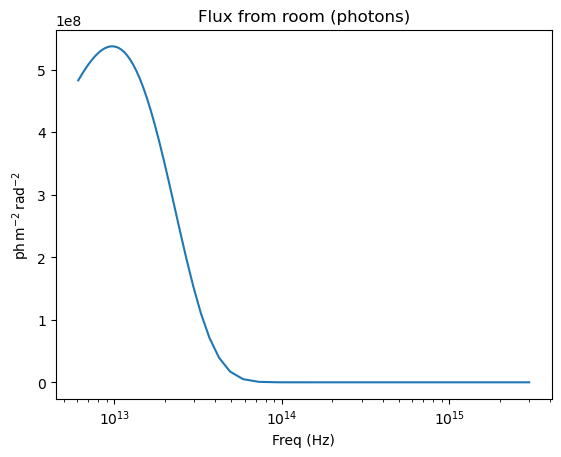

In [17]:
with quantity_support():
    plt.figure()
    plt.plot(wav_room, flux_nu_room_photons)
    #plt.xlabel('Wavelength (um)')
    plt.title('Flux from room (photons)')
    plt.show()

with quantity_support():
    plt.figure()
    plt.semilogx(nu_room, flux_nu_room_photons)
    plt.title('Flux from room (photons)')
    plt.xlabel('Freq (Hz)')
    plt.show()



In [8]:
wav_det = np.linspace(wavel_cuton, wavel_cutoff, 100) # wide range of wavelengths (wider than detector sensitivity)
nu_det = wavel_to_nu(wav_det)

# instantiate
bb_nu_det_warm = models.BlackBody(temperature=Teff_90k)
bb_nu_det_cold = models.BlackBody(temperature=Teff_55k)

# flux in terms of irradiance
flux_nu_det_warm = bb_nu_det_warm(nu_det)
flux_nu_det_cold = bb_nu_det_cold(nu_det)

# flux in terms of photons
flux_nu_det_photons = flux_nu_to_photons(flux_nu_det_warm, nu_det)
flux_nu_det_cold_photons = flux_nu_to_photons(flux_nu_det_cold, nu_det)

# integrate over detector bandwidth (ph s-1 m-2 rad-2)
# note minus sign is to reverse the sign of the flux (since we're integrating from large nu (small wavel) to small nu (large wavel))
photon_rate_total = -np.trapezoid(flux_nu_det_photons, nu_det)
photon_rate_total_cold = -np.trapezoid(flux_nu_det_cold_photons, nu_det)

#photon_rate_total_warm_photons = np.trapz(flux_nu_det_warm_photons, nu_det)

NameError: name 'flux_nu_to_photons' is not defined

In [119]:
# assume photons are coming from entire lower half (factor of 1/2) of the 'hemisphere' of surrounding inner sanctum (factor of pi sr**2)
photon_rate_per_area_on_det_warm = (photon_rate_total_warm * 0.5 * np.pi*u.rad**2).to(u.ph * u.s**-1 * u.m**-2)

In [123]:
# incident photons on detector surface
photon_rate_det_incid_warm = (A_det * photon_rate_per_area_on_det_warm).to(u.ph * u.s**-1)

# incorp. QE
photon_rate_det_absobed_warm = qe_det * photon_rate_det_incid_warm

# per pix
photon_rate_pix_absorbed_warm = photon_rate_det_absobed_warm / N_pixels

In [161]:
# fcn to find photon rate per pixel

def photon_rate_per_pixel(T_det, gain_det = 1):
    '''
    Assumes detector is receiving photons under the hemisphere of the inner sanctum

    INPUTS:
    T_det: temperature of detector (K)
    gain: gain of detector; ADU = e/G (+ offset)

    OUTPUTS
    photon_rate_pix_absorbed: photon rate per pixel (ph s-1)
    '''


    wav_det = np.linspace(wavel_cuton, wavel_cutoff, 100) # wide range of wavelengths (wider than detector sensitivity)
    nu_det = wavel_to_nu(wav_det)

    # instantiate
    bb_nu_det = models.BlackBody(temperature=T_det)

    # flux in terms of irradiance
    flux_nu_det = bb_nu_det(nu_det)

    # flux in terms of photons
    flux_nu_det_photons = flux_nu_photons(flux_nu_det, nu_det)

    # integrate over detector bandwidth; units (ph s-1 m-2 rad-2)
    # note minus sign is to reverse the sign of the flux (since we're integrating from large nu (small wavel) to small nu (large wavel))
    photon_rate_total = -np.trapezoid(flux_nu_det_photons, nu_det)

    # assume photons are coming from entire lower half (factor of 1/2) of the 'hemisphere' of surrounding inner sanctum (factor of pi sr**2)
    photon_rate_per_area_on_det = (photon_rate_total * 0.5 * np.pi*u.rad**2).to(u.ph * u.s**-1 * u.m**-2)

    # incident photons on detector surface
    photon_rate_det_incid = (A_det * photon_rate_per_area_on_det).to(u.ph * u.s**-1)

    # incorp. QE, gain
    photon_rate_det_absobed = qe_det * photon_rate_det_incid

    # per pix
    photon_rate_pix_absorbed = photon_rate_det_absobed / N_pixels
    adu_rate_pix_absorbed = (photon_rate_pix_absorbed / u.photon) / gain_det

    return photon_rate_pix_absorbed, adu_rate_pix_absorbed


In [172]:
photon_rate_pix_absorbed_hot = photon_rate_per_pixel(T_det = 273*u.K, gain_det = 1)
photon_rate_pix_absorbed_warm = photon_rate_per_pixel(T_det = 90*u.K, gain_det = 1)
photon_rate_pix_absorbed_cold = photon_rate_per_pixel(T_det = 55*u.K, gain_det = 1)

photon_rate_pix_absorbed_tuning = photon_rate_per_pixel(T_det = 105*u.K, gain_det = 1)

print(photon_rate_pix_absorbed_hot)
print(photon_rate_pix_absorbed_warm)
print(photon_rate_pix_absorbed_cold)
print(photon_rate_pix_absorbed_tuning)

(<Quantity 9.74952895e+09 ph / (s pix2)>, <Quantity 9.74952895e+09 1 / (s pix2)>)
(<Quantity 4.67593732 ph / (s pix2)>, <Quantity 4.67593732 1 / (s pix2)>)
(<Quantity 1.29519799e-08 ph / (s pix2)>, <Quantity 1.29519799e-08 1 / (s pix2)>)
(<Quantity 409.6353769 ph / (s pix2)>, <Quantity 409.6353769 1 / (s pix2)>)


In [165]:
T_array = np.linspace(55, 273, 100) * u.K
adu_rate_pix_absorbed_vs_temp = u.Quantity(
    [photon_rate_per_pixel(T)[1] for T in T_array]
)

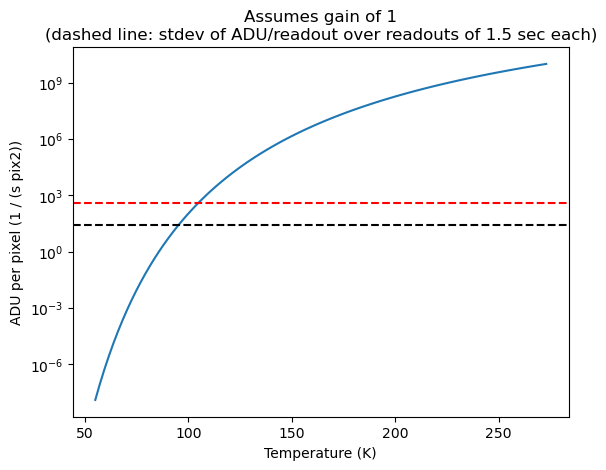

In [173]:
plt.semilogy(T_array, adu_rate_pix_absorbed_vs_temp)
plt.xlabel(f'Temperature ({T_array.unit})')
plt.ylabel(f'ADU per pixel ({adu_rate_pix_absorbed_vs_temp.unit})')
plt.axhline(y = 25, color = 'k', linestyle = '--')
plt.axhline(y = 409, color = 'r', linestyle = '--')
#plt.axvline(x=90, color = 'k', linestyle = '--')
plt.title('Assumes gain of 1\n(dashed line: stdev of ADU/readout over readouts of 1.5 sec each)')
plt.show()